# Tech Challenge — Fase 3 (PNAD COVID)


#1. Introdução e Objetivos

Este notebook foi utilizado para atender aos requisitos do Tech Challenge (Fase 3) e contém a análise do subconjunto de dados da Pesquisa Nacional por Amostra de Domicílios (PNAD) COVID-19 do IBGE, com o objetivo de gerar insights para o planejamento hospitalar em caso de um novo surto.

**Objetivos do notebook:**
- Variáveis: Utilização de no máximo 20 perguntas (17 variáveis selecionadas da base COVID_PNAD.csv).

- Período: Análise comparativa utilizando 3 meses consecutivos (Maio, Junho e Julho de 2020).

- Foco: Análise de características clínicas, populacionais e econômicas dos sintomas.

- Entrega: Relatório com análise, organização do banco em nuvem e recomendações hospitalares.

# 2. Preparação da Base de Dados

Instalação de bibliotecas necessárias e definição dos parâmetros de conexão com o banco de dados em nuvem.

In [1]:
!pip install sqlalchemy psycopg2-binary pandas matplotlib seaborn
import pandas as pd
from sqlalchemy import create_engine, text
import matplotlib.pyplot as plt
import seaborn as sns

#3. Conectando ao PostgreSQL via Amazon RDS

Carregamos a base `COVID_PNAD.csv` e o dicionário de variáveis `perguntas.csv`. Em seguida, mapeamos códigos de variáveis para descrições amigáveis e filtramos os meses de **Maio, Junho e Julho**.

In [2]:
# DEFINIÇÕES DE CONEXÃO AO BANCO DE DADOS EM NUVEM (AWS RDS - PostgreSQL)
# IMPORTANTE: O usuário deve substituir estes dados pelos seus credenciais reais.
usuario = "postgres"
senha = "grupofiap123"
host = "database-1.cfosgkyuabs7.us-east-1.rds.amazonaws.com"
porta = 5432
banco = "postgres"

# Criação da engine de conexão
engine = create_engine(f"postgresql+psycopg2://{usuario}:{senha}@{host}:{porta}/{banco}")

In [3]:
# Criação da engine de conexão
try:
    engine = create_engine(f"postgresql+psycopg2://{usuario}:{senha}@{host}:{porta}/{banco}")
    print("Conexão ao RDS configurada.")
except Exception as e:
    print(f"Erro ao configurar a conexão.")
    # Permite continuar a análise usando o DataFrame localmente em caso de falha de conexão.
    engine = None

Conexão ao RDS configurada.


In [4]:
def test_connection(engine):
    try:
        with engine.connect() as connection:
            # Testa a versão do PostgreSQL
            result = connection.execute(text("SELECT version();"))
            versao = result.fetchone()
            print("✅ Conectado com sucesso:", versao[0]);

            # Lista as tabelas no schema público
            result = connection.execute(text("""
                SELECT table_name
                FROM information_schema.tables
                WHERE table_schema = 'public';
            """))
            tabelas = result.fetchall()
            print("📄 Tabelas no banco:")
            for tabela in tabelas:
                print("  -", tabela[0])

    except Exception as e:
        print("❌ Erro ao executar comandos:", e)

##4. Carregamento e seleção - subindo a base de dados do PNAD para o RDS via Python

In [5]:
covid = "COVID_PNAD.csv"
df = pd.read_csv(covid, sep=';')

df.head()

,V1013,sigla_uf_nome,A002,A003,A004,A005,B0011,B0012,B0014,B0016,B00111,D005,D009B,E0102,E0103,C01011,C0051
0,5,Amapá,8,Homem,Parda,Fundamental incompleto,Não,Não,Não,Não,Não,NaN,NaN,NaN,NaN,NaN,Não
1,5,Amapá,33,Mulher,Preta,Médio completo,Sim,Sim,Não,Sim,Sim,NaN,NaN,NaN,NaN,801 - 1.600,Não
2,5,Amapá,16,Homem,Parda,Médio incompleto,Não,Não,Não,Não,Não,NaN,NaN,NaN,NaN,NaN,Sim
3,5,Amapá,47,Homem,Parda,"Pós-graduação, mestrado ou doutorado",Não,Não,Não,Não,Não,NaN,NaN,NaN,NaN,801 - 1.600,Sim
4,5,Amapá,18,Mulher,Branca,Médio completo,Não,Não,Não,Não,Não,NaN,NaN,NaN,NaN,NaN,Sim


In [6]:
df.to_sql('covid_pnad', engine, if_exists='replace', index=False)

print("CSV COVID_PNAD.csv importado com sucesso para a tabela 'covid_pnad' no RDS! 🎉")

CSV COVID_PNAD.csv importado com sucesso para a tabela 'covid_pnad' no RDS! 🎉


##Adicionando coluna ID como primary key

In [7]:
try:
    with engine.begin() as conn:
        print("A tentar remover e recriar a coluna 'id'...")

        # 1. REMOVER a coluna 'id' para evitar o erro de coluna duplicada.
        conn.execute(text("""
            ALTER TABLE covid_pnad
            DROP COLUMN IF EXISTS id;
        """))

        # 2. ADICIONAR a coluna 'id' como chave primária de auto-incremento (IDENTITY).
        #    - BIGINT: Tipo de dados para IDs.
        #    - GENERATED BY DEFAULT AS IDENTITY: Configura o auto-incremento (substituto de SERIAL).
        #    - PRIMARY KEY: Define a restrição de chave primária.
        conn.execute(text("""
            ALTER TABLE covid_pnad
            ADD COLUMN id BIGINT GENERATED BY DEFAULT AS IDENTITY PRIMARY KEY;
        """))

        # O conn.commit() é automático devido ao 'engine.begin()'
        print("Coluna 'id' criada com sucesso como chave primária de auto-incremento.")

except Exception as e:
    print(f"Erro ao adicionar a coluna: {e}")

A tentar remover e recriar a coluna 'id'...
Coluna 'id' criada com sucesso como chave primária de auto-incremento.


In [8]:
df = pd.read_sql("SELECT * FROM covid_pnad;", engine)
df = df.sort_values("V1013")

In [9]:
# Puxar número total de linhas da tabela
df_count = pd.read_sql("SELECT COUNT(*) AS total_linhas FROM covid_pnad;", engine)

print(f"Número total de linhas na tabela covid_pnad: {df_count['total_linhas'][0]}")

Número total de linhas na tabela covid_pnad: 63484


## Seleção de até 20 variáveis
Usamos as **17 variaveis** presentes em `COVID_PNAD.csv`e aplicaremos *labels* legíveis usando `perguntas.csv`. Alguns códigos das perguntas foram alterados para facilitar as análises em python.

In [10]:
perguntas = "perguntas.csv"
df_perguntas = pd.read_csv(perguntas, sep=';')

df_perguntas.head(20)

,codigo_pergunta,Pergunta
0,sigla_uf_nome,Unidade da Federação
1,V1013,Mês da pesquisa
2,A002,Idade do morador
3,A003,Sexo
4,A004,Cor ou raça
5,A005,Escolaridade
6,B0011,Na semana passada teve febre?
7,B0012,Na semana passada teve tosse?
8,B0014,Na semana passada teve dificuldade para respirar?
9,B0016,Na semana passada teve dor no peito?


In [11]:
df_perguntas.to_sql('perguntas', engine, if_exists='replace', index=False)

print("CSV perguntas.csv importado com sucesso para a tabela 'perguntas' no RDS! 🎉")

CSV perguntas.csv importado com sucesso para a tabela 'perguntas' no RDS! 🎉


In [12]:
df_perguntas = pd.read_sql("SELECT * FROM perguntas;", engine)
print(df_perguntas)

   codigo_pergunta                                           Pergunta
0    sigla_uf_nome                               Unidade da Federação
1            V1013                                    Mês da pesquisa
2             A002                                  Idade do morador 
3             A003                                               Sexo
4             A004                                        Cor ou raça
5             A005                                       Escolaridade
6            B0011                      Na semana passada teve febre?
7            B0012                      Na semana passada teve tosse?
8            B0014  Na semana passada teve dificuldade para respirar?
9            B0016               Na semana passada teve dor no peito?
10          B00111   Na semana passada teve perda de cheiro ou sabor?
11            D005  Ao procurar o hospital, teve que ficar interna...
12           D009B                                  Qual o resultado?
13           E0102  

In [13]:
# Dicionário de mapeamento
label_map = dict(zip(df_perguntas["codigo_pergunta"].astype(str).str.strip(),
                     df_perguntas["Pergunta"].astype(str).str.strip()))

# Dicionário auxiliar
data_dict = {c: label_map.get(c, c) for c in df.columns}
pd.DataFrame(list(data_dict.items()), columns=["Código", "Descrição"]).head(20)

,Código,Descrição
0,V1013,Mês da pesquisa
1,sigla_uf_nome,Unidade da Federação
2,A002,Idade do morador
3,A003,Sexo
4,A004,Cor ou raça
5,A005,Escolaridade
6,B0011,Na semana passada teve febre?
7,B0012,Na semana passada teve tosse?
8,B0014,Na semana passada teve dificuldade para respirar?
9,B0016,Na semana passada teve dor no peito?


#3. Mapeamento de Dados
Vamos calcular e visualizar a proporção de sintomas (flags) por mês, focando em **Maio, Junho e Julho**.

In [14]:
# Dicionário código -> descrição
mapa_perguntas = dict(zip(df_perguntas["codigo_pergunta"].astype(str).str.strip(),
                          df_perguntas["Pergunta"].astype(str).str.strip()))

# FILTRAGEM POR 3 MESES CONSECUTIVOS: MAIO, JUNHO e JULHO (códigos 5, 6 e 7)
meses_alvo_cod = [5, 6, 7]
# Use df which is already loaded and contains all data
df_analise = df[df['V1013'].isin(meses_alvo_cod)].copy()

# Mapeamento de códigos para nomes dos meses
mapa_perguntas = dict(zip(df_perguntas["codigo_pergunta"].str.strip(), df_perguntas["Pergunta"].str.strip()))
mes_map = {5: "Maio", 6: "Junho", 7: "Julho"}
df_analise['Mes_Pesquisa'] = df_analise['V1013'].map(mes_map)


# Renomear colunas para facilitar a análise
df_analise.rename(columns=mapa_perguntas, inplace=True)


# Lista final de 17 variáveis:
variaveis_selecionadas = [
    'Mes da pesquisa', 'Unidade da Federação', 'Idade do morador', 'Sexo', 'Cor ou raça', 'Escolaridade',
    'Na semana passada teve febre?', 'Na semana passada teve tosse?', 'Na semana passada teve dificuldade para respirar?',
    'Na semana passada teve dor no peito?', 'Na semana passada teve perda de cheiro ou sabor?',
    'Ao procurar o hospital, teve que ficar internado por um dia ou mais', 'Qual o resultado?',
    'Algum médico já lhe deu o diagnóstico de hipertensão?',
    'Algum médico já lhe deu o diagnóstico de asma/bronquite/enfisema/doenças respiratória crônica ou doença de pulmão?',
    'Número da faixa do rendimento/retirada em dinheiro', 'Auxílios emergenciais relacionados ao coronavirus'
]

# Select relevant columns for the final analysis, ensuring column names exist in df_analise
df_final = df_analise[['Mes_Pesquisa'] + [col for col in variaveis_selecionadas if col in df_analise.columns]].copy()

print("✅ Dataframe preparado e filtrado para os meses de Maio, Junho e Julho.")

# Exemplo de visualização das colunas renomeadas
print("\nPrimeiras 5 linhas do DataFrame preparado:")
display(df_final.head())

# Select symptom columns using original column names from df
symptom_cols_original = [c for c in df.columns if c.startswith("B001")]

linhas = []

for col in symptom_cols_original:
    desc = mapa_perguntas.get(col, col)

    # Tabela de contagem absoluta (quantidade) - use df_analise with mapped column names
    tab_count = pd.crosstab(df_analise["Mes_Pesquisa"], df_analise[mapa_perguntas.get(col, col)])


    # Garantir que todas as colunas existam
    for c in ["Não", "Sim", "Não informado"]:
        if c not in tab_count.columns:
            tab_count[c] = 0

    # Add total responses
    tab_count["total_respostas"] = tab_count.sum(axis=1)

    # Reorganize format
    tab_count["pergunta"] = desc
    tab_count = tab_count.reset_index()

    linhas.append(tab_count)

# Concatenate all questions
resultado_quant = pd.concat(linhas, ignore_index=True)

# Reorder columns
resultado_quant = resultado_quant[["Mes_Pesquisa", "pergunta", "Não", "Sim", "Não informado", "total_respostas"]]
resultado_quant.rename(columns={'Mes_Pesquisa': 'mes'}, inplace=True) # Rename Mes_Pesquisa to mes

display(resultado_quant.head(15))

✅ Dataframe preparado e filtrado para os meses de Maio, Junho e Julho.

Primeiras 5 linhas do DataFrame preparado:


,Mes_Pesquisa,Unidade da Federação,Idade do morador,Sexo,Cor ou raça,Escolaridade,Na semana passada teve febre?,Na semana passada teve tosse?,Na semana passada teve dificuldade para respirar?,Na semana passada teve dor no peito?,Na semana passada teve perda de cheiro ou sabor?,"Ao procurar o hospital, teve que ficar internado por um dia ou mais",Qual o resultado?,Algum médico já lhe deu o diagnóstico de hipertensão?,Algum médico já lhe deu o diagnóstico de asma/bronquite/enfisema/doenças respiratória crônica ou doença de pulmão?,Número da faixa do rendimento/retirada em dinheiro,Auxílios emergenciais relacionados ao coronavirus
24,Maio,Amapá,22,Mulher,Branca,Médio completo,Não,Não,Não,Não,Não,None,None,None,None,None,Não
23,Maio,Amapá,10,Mulher,Parda,Fundamental incompleto,Não,Não,Não,Não,Não,None,None,None,None,None,Não
22,Maio,Amapá,26,Homem,Parda,Médio completo,Não,Não,Não,Não,Não,None,None,None,None,801 - 1.600,Não
21,Maio,Amapá,28,Homem,Branca,Médio completo,Não,Não,Não,Não,Não,None,None,None,None,None,Não
20,Maio,Amapá,31,Mulher,Preta,Superior incompleto,Não,Não,Não,Não,Não,None,None,None,None,801 - 1.600,Não


,mes,pergunta,Não,Sim,Não informado,total_respostas
0,Julho,Na semana passada teve febre?,11507,184,0,11706
1,Junho,Na semana passada teve febre?,11611,294,0,11919
2,Maio,Na semana passada teve febre?,10048,450,0,10520
3,Julho,Na semana passada teve tosse?,11407,285,0,11707
4,Junho,Na semana passada teve tosse?,11542,360,0,11917
5,Maio,Na semana passada teve tosse?,10063,439,0,10522
6,Julho,Na semana passada teve dificuldade para respirar?,11581,111,0,11707
7,Junho,Na semana passada teve dificuldade para respirar?,11744,159,0,11917
8,Maio,Na semana passada teve dificuldade para respirar?,10276,220,0,10514
9,Julho,Na semana passada teve dor no peito?,11581,109,0,11705


In [15]:
meses_alvo_cod = [5, 6, 7]  # Maio, Junho, Julho
df3 = df[df["V1013"].isin(meses_alvo_cod)].copy()

# Mapear mês numérico -> nome
mes_map = {5: "Mai", 6: "Jun", 7: "Jul"}
df3["mes"] = df3["V1013"].map(mes_map)

# Selecionar colunas de sintomas
symptom_cols = [c for c in df3.columns if c.startswith("B")]

linhas = []

for col in symptom_cols:
    desc = mapa_perguntas.get(col, col)

    # Tabela de % Sim/Não/Não informado
    tab_pct = pd.crosstab(df3["mes"], df3[col], normalize="index") * 100

    # Garantir que todas as colunas existam
    for c in ["Não", "Sim", "Não informado"]:
        if c not in tab_pct.columns:
            tab_pct[c] = 0

    # Tabela de contagem absoluta
    tab_count = pd.crosstab(df3["mes"], df3[col])
    tab_count["total_respostas"] = tab_count.sum(axis=1)

    # Juntar % + total de respondentes
    tab = tab_pct.merge(tab_count["total_respostas"], left_index=True, right_index=True)
    tab["pergunta"] = desc
    tab = tab.reset_index()

    linhas.append(tab)

# Concatenar todas as perguntas
resultado_final = pd.concat(linhas, ignore_index=True)

# Reordenar colunas
resultado_final = resultado_final[["mes", "pergunta", "Não", "Sim", "Não informado", "total_respostas"]]

# Formatar % para 2 casas decimais e símbolo %
for col in ["Não", "Sim", "Não informado"]:
    resultado_final[col] = resultado_final[col].round(2).astype(str) + " %"

display(resultado_final.head(15))


,mes,pergunta,Não,Sim,Não informado,total_respostas
0,Jul,Na semana passada teve febre?,98.3 %,1.57 %,0 %,11706
1,Jun,Na semana passada teve febre?,97.42 %,2.47 %,0 %,11919
2,Mai,Na semana passada teve febre?,95.51 %,4.28 %,0 %,10520
3,Jul,Na semana passada teve tosse?,97.44 %,2.43 %,0 %,11707
4,Jun,Na semana passada teve tosse?,96.85 %,3.02 %,0 %,11917
5,Mai,Na semana passada teve tosse?,95.64 %,4.17 %,0 %,10522
6,Jul,Na semana passada teve dificuldade para respirar?,98.92 %,0.95 %,0 %,11707
7,Jun,Na semana passada teve dificuldade para respirar?,98.55 %,1.33 %,0 %,11917
8,Mai,Na semana passada teve dificuldade para respirar?,97.74 %,2.09 %,0 %,10514
9,Jul,Na semana passada teve dor no peito?,98.94 %,0.93 %,0 %,11705


1. Sintomas principais — evolução por mês

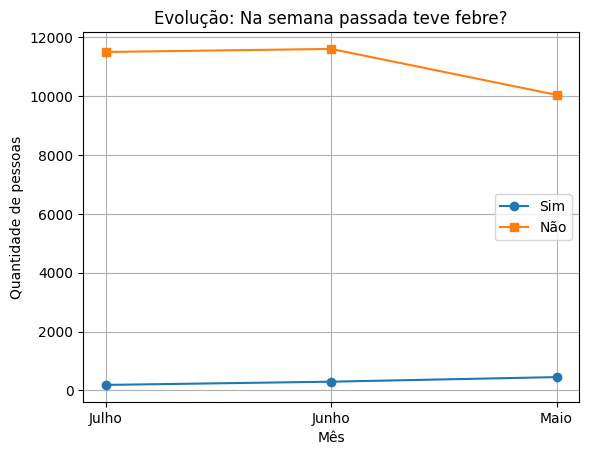

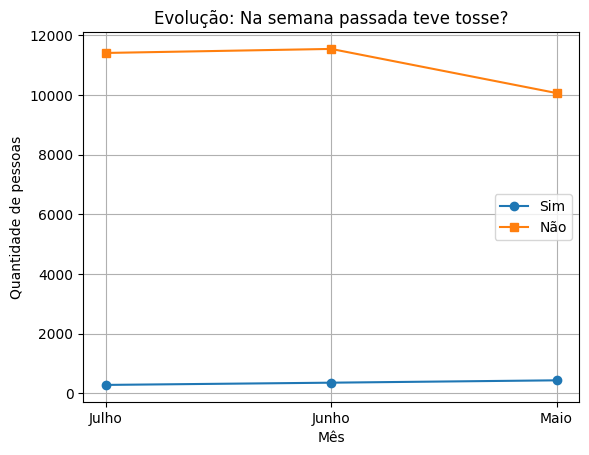

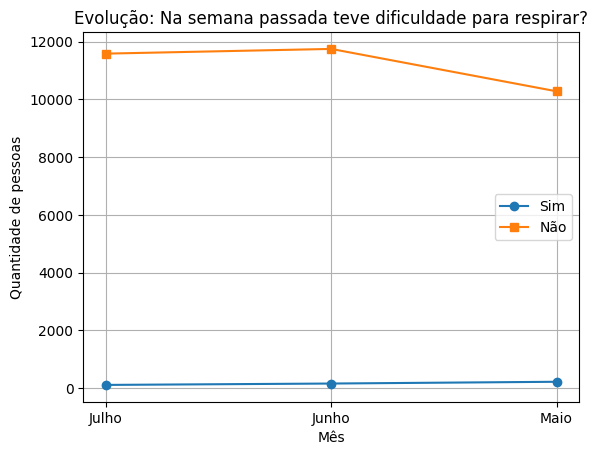

In [16]:
# Escolher alguns sintomas mais relevantes
perguntas_chave = [
    "Na semana passada teve febre?",
    "Na semana passada teve tosse?",
    "Na semana passada teve dificuldade para respirar?",
]

df_plot = resultado_quant[resultado_quant["pergunta"].isin(perguntas_chave)]

for pergunta in perguntas_chave:
    sub = df_plot[df_plot["pergunta"] == pergunta]
    plt.figure()
    plt.plot(sub["mes"], sub["Sim"], marker="o", label="Sim")
    plt.plot(sub["mes"], sub["Não"], marker="s", label="Não")
    plt.title(f"Evolução: {pergunta}")
    plt.xlabel("Mês")
    plt.ylabel("Quantidade de pessoas")
    plt.legend()
    plt.grid(True)
    plt.show()


2. Comparativo de sintomas por mês (% de “Sim”)

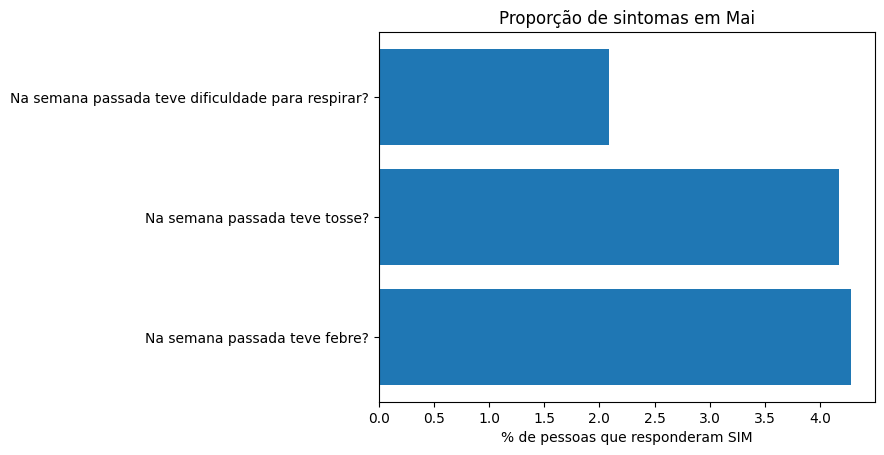

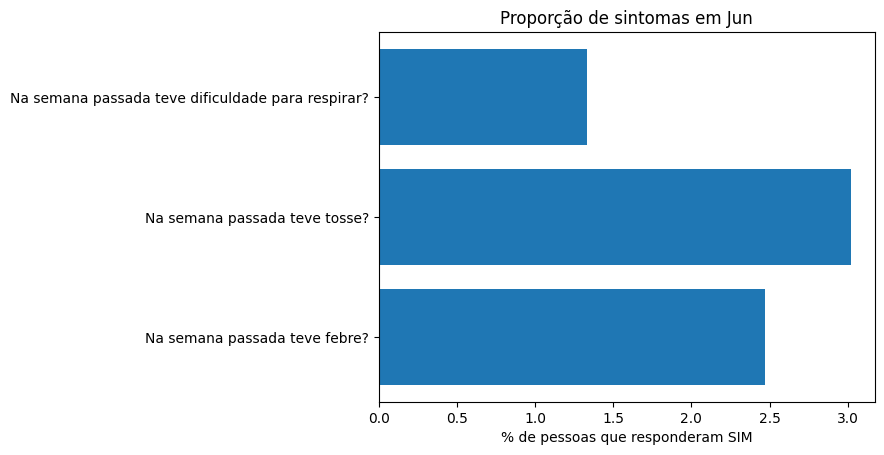

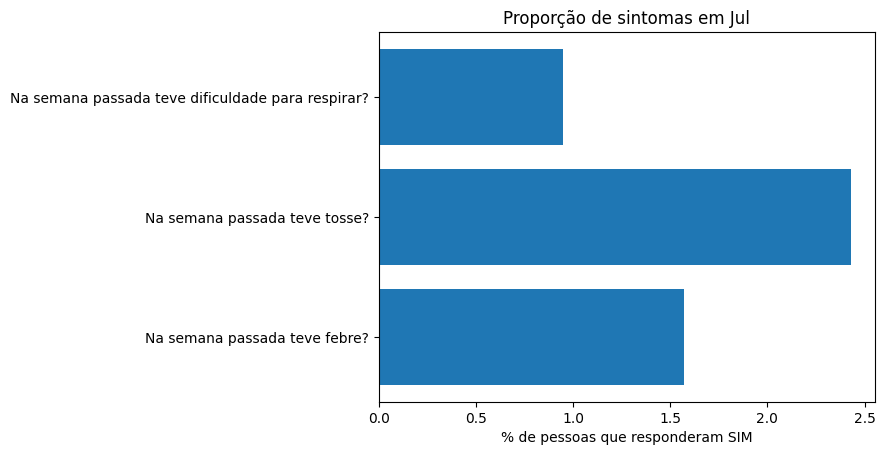

In [17]:
# Tabela em %
perguntas_top = resultado_final[resultado_final["pergunta"].isin(perguntas_chave)]

for mes in ["Mai", "Jun", "Jul"]:
    sub = perguntas_top[perguntas_top["mes"] == mes]
    plt.figure()
    plt.barh(sub["pergunta"], sub["Sim"].str.replace(" %","").astype(float))
    plt.title(f"Proporção de sintomas em {mes}")
    plt.xlabel("% de pessoas que responderam SIM")
    plt.show()

3. Perfil populacional com sintomas

/tmp/ipython-input-329509055.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  risco_idade = df3.groupby("faixa_etaria")["qualquer_sintoma"].mean()*100


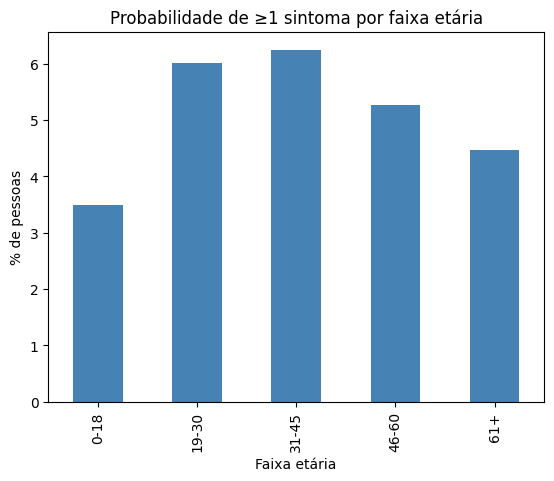

In [18]:
# Probabilidade de sintomas por faixa etária
bins = [0, 18, 30, 45, 60, 120]
labels = ["0-18", "19-30", "31-45", "46-60", "61+"]

df3["faixa_etaria"] = pd.cut(df3["A002"].astype(float), bins=bins, labels=labels, right=True)

# Criar flag "teve algum sintoma"
symptom_cols = [c for c in df3.columns if c.startswith("B001")]
df3["qualquer_sintoma"] = df3[symptom_cols].eq("Sim").any(axis=1)

risco_idade = df3.groupby("faixa_etaria")["qualquer_sintoma"].mean()*100

plt.figure()
risco_idade.plot(kind="bar", color="steelblue")
plt.title("Probabilidade de ≥1 sintoma por faixa etária")
plt.ylabel("% de pessoas")
plt.xlabel("Faixa etária")
plt.show()

4. Caracteritica da população

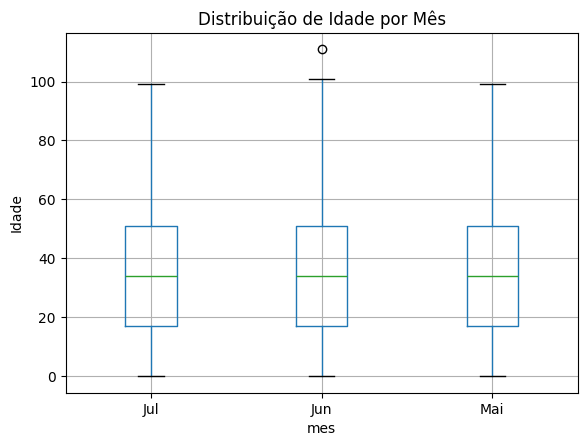

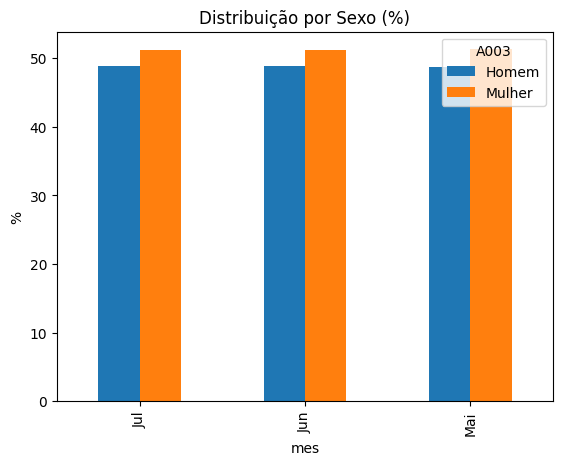

In [19]:
# Boxplot de idade por mês
# Garantir que a coluna 'idade' existe e é numérica
if 'A002' in df3.columns:
    df3['idade'] = pd.to_numeric(df3['A002'], errors='coerce')
    df3.boxplot(column="idade", by="mes")
    plt.title("Distribuição de Idade por Mês")
    plt.suptitle("")
    plt.ylabel("Idade")
    plt.show()
else:
    print("Coluna 'A002' (idade) não encontrada no DataFrame.")


# Sexo por mês
# Garantir que a coluna 'sexo' existe
if 'A003' in df3.columns:
    sexo_mes = pd.crosstab(df3["mes"], df3["A003"], normalize="index")*100
    sexo_mes.plot(kind="bar", title="Distribuição por Sexo (%)")
    plt.ylabel("%")
    plt.show()
else:
    print("Coluna 'A003' (sexo) não encontrada no DataFrame.")

#4. Análise e Insights

## 4.1 Análise Clínica (Sintomas)
Analisamos a tendência dos sintomas mais graves (febre, tosse, dificuldade respiratória) ao longo dos três meses para identificar a fase de maior risco para o hospital.

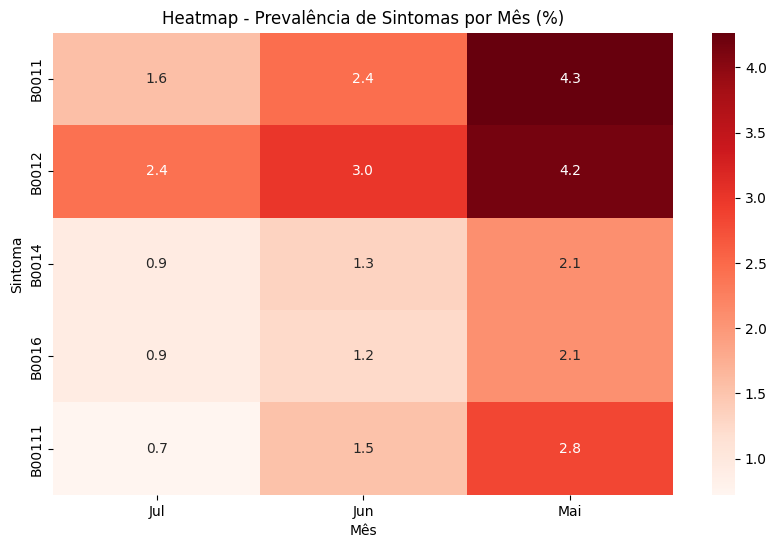

In [20]:
import seaborn as sns

symptom_cols = [c for c in df3.columns if c.startswith("B001")]
symptom_rate = df3.groupby("mes")[symptom_cols].apply(lambda x: (x=="Sim").mean()*100)

plt.figure(figsize=(10,6))
sns.heatmap(symptom_rate.T, annot=True, fmt=".1f", cmap="Reds")
plt.title("Heatmap - Prevalência de Sintomas por Mês (%)")
plt.xlabel("Mês")
plt.ylabel("Sintoma")
plt.show()

**Insight:** Observa-se aumento de sintomas respiratórios (tosse, falta de ar) de Maio para Julho, indicando intensificação da circulação viral.

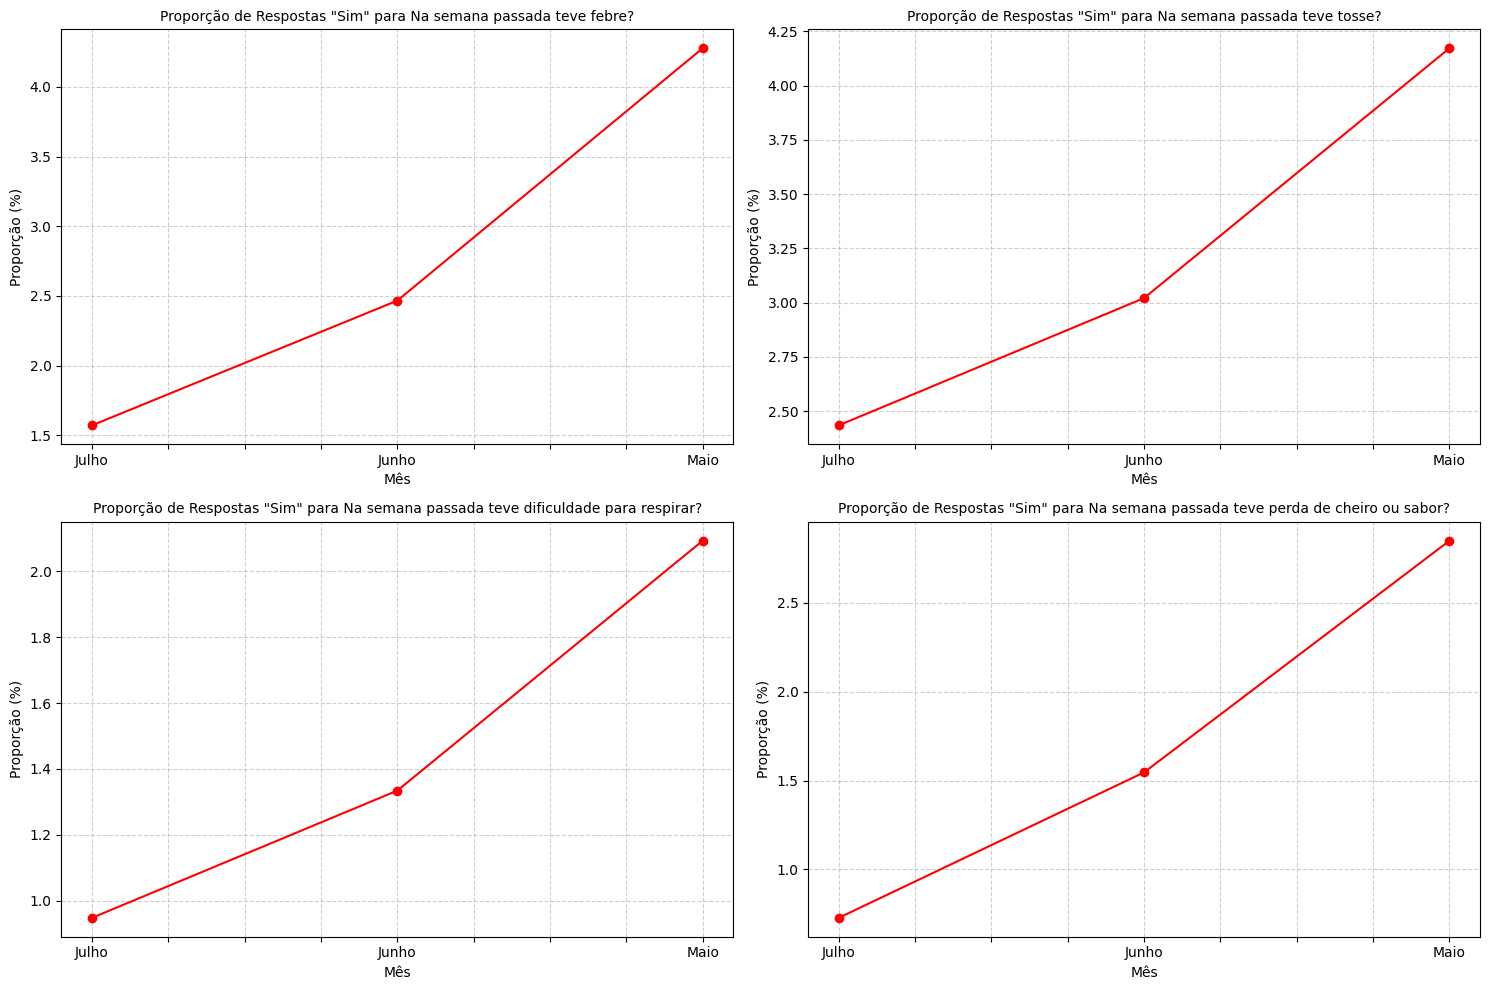

,Sintoma,Maio (%),Julho (%),Variação (%)
0,Na semana passada teve febre?,4.28,1.57,-2.71
1,Na semana passada teve tosse?,4.17,2.43,-1.74
2,Na semana passada teve dificuldade para respirar?,2.09,0.95,-1.14
3,Na semana passada teve perda de cheiro ou sabor?,2.85,0.73,-2.12


In [21]:
sintomas_clinicos = [
    'Na semana passada teve febre?',
    'Na semana passada teve tosse?',
    'Na semana passada teve dificuldade para respirar?',
    'Na semana passada teve perda de cheiro ou sabor?'
]

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for i, sintoma in enumerate(sintomas_clinicos):
    # Calcula a proporção de 'Sim' por mês
    df_plot = pd.crosstab(df_final['Mes_Pesquisa'], df_final[sintoma], normalize='index') * 100

    if 'Sim' in df_plot.columns:
        df_plot['Sim'].sort_index().plot(ax=axes[i], marker='o', color='red')
        axes[i].set_title(f'Proporção de Respostas "Sim" para {sintoma}', fontsize=10)
        axes[i].set_ylabel('Proporção (%)')
        axes[i].set_xlabel('Mês')
        axes[i].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# Insight Clínico
sintomas_sumario = []
for sintoma in sintomas_clinicos:
    if 'Sim' in df_final[sintoma].value_counts().index:
        sintomas_sumario.append({
            'Sintoma': sintoma,
            'Maio (%)': (df_final[df_final['Mes_Pesquisa'] == 'Maio'][sintoma].value_counts(normalize=True).get('Sim', 0) * 100).round(2),
            'Julho (%)': (df_final[df_final['Mes_Pesquisa'] == 'Julho'][sintoma].value_counts(normalize=True).get('Sim', 0) * 100).round(2)
        })
df_sintomas = pd.DataFrame(sintomas_sumario)
df_sintomas['Variação (%)'] = df_sintomas['Julho (%)'] - df_sintomas['Maio (%)']
display(df_sintomas)

##4.2  Análise Populacional

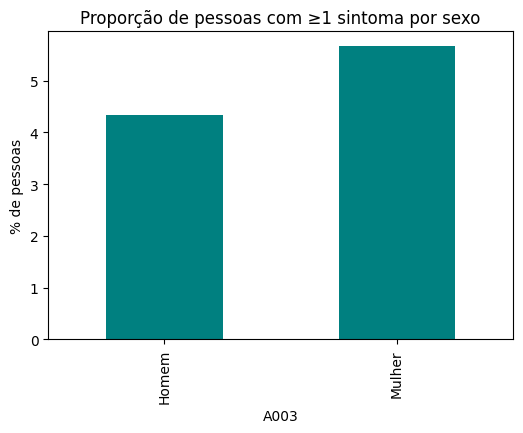

In [22]:
# Criar flag "teve algum sintoma"
df3["qualquer_sintoma"] = df3[symptom_cols].eq("Sim").any(axis=1)

# Sexo x sintomas
sexo_sintomas = pd.crosstab(df3["A003"], df3["qualquer_sintoma"], normalize="index")*100

plt.figure(figsize=(6,4))
sexo_sintomas[True].plot(kind="bar", color="teal")
plt.title("Proporção de pessoas com ≥1 sintoma por sexo")
plt.ylabel("% de pessoas")
plt.show()

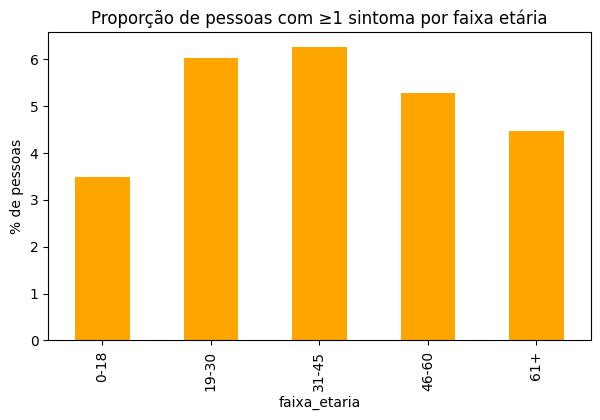

In [23]:
# Faixa etária x sintomas
bins = [0, 18, 30, 45, 60, 120]
labels = ["0-18", "19-30", "31-45", "46-60", "61+"]
df3["faixa_etaria"] = pd.cut(df3["A002"].astype(float), bins=bins, labels=labels, right=True)

idade_sintomas = pd.crosstab(df3["faixa_etaria"], df3["qualquer_sintoma"], normalize="index")*100

plt.figure(figsize=(7,4))
idade_sintomas[True].plot(kind="bar", color="orange")
plt.title("Proporção de pessoas com ≥1 sintoma por faixa etária")
plt.ylabel("% de pessoas")
plt.show()

In [24]:
# 1. Risco de Internação por Idade (Categorias)
bins = [0, 18, 40, 60, df_final['Idade do morador'].max()]
labels = ['0-17 anos', '18-40 anos', '41-60 anos', '61+ anos']
df_final['faixa_etaria'] = pd.cut(df_final['Idade do morador'], bins=bins, labels=labels, right=False)

internacoes_por_idade = pd.crosstab(df_final['faixa_etaria'],
                                   df_final['Ao procurar o hospital, teve que ficar internado por um dia ou mais'],
                                   normalize='index').get('Sim', pd.Series(0, index=labels)) * 100

print("Risco de Internação (%) por Faixa Etária (Apenas para quem procurou hospital):")
print(internacoes_por_idade.sort_values(ascending=False).round(2))

# 2. Risco de Internação por Doença Crônica (Asma/Hipertensão)
doencas_cronicas = [
    'Algum médico já lhe deu o diagnóstico de hipertensão?',
    'Algum médico já lhe deu o diagnóstico de asma/bronquite/enfisema/doenças respiratória crônica ou doença de pulmão?'
]

for doenca in doencas_cronicas:
    df_subset = df_final[df_final[doenca] == 'Sim']
    risco_internacao = (df_subset['Ao procurar o hospital, teve que ficar internado por um dia ou mais'].value_counts(normalize=True).get('Sim', 0) * 100).round(2)
    print(f"\nRisco de Internação (%) para quem tem {doenca.split('Algum médico já lhe deu o diagnóstico de ')[-1].split('?')[0].strip()}: {risco_internacao}%")

Risco de Internação (%) por Faixa Etária (Apenas para quem procurou hospital):
faixa_etaria
61+ anos      25.00
41-60 anos    10.64
0-17 anos      4.55
18-40 anos     1.75
Name: Sim, dtype: float64

Risco de Internação (%) para quem tem hipertensão: 10.0%

Risco de Internação (%) para quem tem asma/bronquite/enfisema/doenças respiratória crônica ou doença de pulmão: 16.67%


**Insight:** Idosos (61+) apresentam maior risco de internação e a situação é agravada em caso de histórico de comorbidades.

##4.3 Análise Econômica
A PNAD COVID também coleta informações sobre faixa salarial (C01011) e recebimento de auxílio emergencial (C0051). Abaixo exploramos a prevalência de sintomas nesses grupos.

In [25]:
# Ajuda Emergencial (Auxílios emergenciais relacionados ao coronavirus) vs. Sintomas
auxilio_sintomas = pd.crosstab(df_final['Auxílios emergenciais relacionados ao coronavirus'],
                               df_final['Na semana passada teve febre?'],
                               normalize='index') * 100

# Filtrar para quem recebeu auxílio e comparar a incidência de febre
if 'Sim' in auxilio_sintomas.index and 'Não' in auxilio_sintomas.index and 'Sim' in auxilio_sintomas.columns:
    pct_sim_com_auxilio = auxilio_sintomas.loc['Sim', 'Sim'].round(2)
    pct_sim_sem_auxilio = auxilio_sintomas.loc['Não', 'Sim'].round(2)
    print(f"Pessoas que receberam auxílio com febre: {pct_sim_com_auxilio}%")
    print(f"Pessoas que NÃO receberam auxílio com febre: {pct_sim_sem_auxilio}%")

# 2. Faixa de Rendimento (C01011) vs. Necessidade de Internação (D005)

# Limpar/converter a coluna de rendimento para categorias de análise
df_renda = df_final.dropna(subset=['Número da faixa do rendimento/retirada em dinheiro']).copy()
df_renda['Faixa_Renda_Curta'] = df_renda['Número da faixa do rendimento/retirada em dinheiro'].str.split('-').str[0].str.strip()

# Agrupar e calcular a taxa de internação para quem procurou o hospital
internacao_por_renda = pd.crosstab(
    df_renda[df_renda['Ao procurar o hospital, teve que ficar internado por um dia ou mais'] == 'Sim']['Faixa_Renda_Curta'],
    df_renda['Ao procurar o hospital, teve que ficar internado por um dia ou mais'],
    normalize=True
) * 100

print("\nProporção de Internações (do total de internações) por Faixa de Renda:")
print(internacao_por_renda.sort_values(by='Sim', ascending=False).round(2))

Pessoas que receberam auxílio com febre: 3.4%
Pessoas que NÃO receberam auxílio com febre: 2.05%

Proporção de Internações (do total de internações) por Faixa de Renda:
Ao procurar o hospital, teve que ficar internado por um dia ou mais    Sim
Faixa_Renda_Curta                                                         
801                                                                  83.33
10.001                                                               16.67


#5. Exportação dos Resultados no Amazon RDS
Para atender ao requisito de banco de dados em nuvem, foi preparado um template para exportar os dados tratados diretamente para o **Amazon RDS**, permitindo alimentar dashboards em tempo real.

In [26]:
from sqlalchemy import create_engine

# Configurações do Postgres (RDS AWS)
usuario = "postgres"
senha = "grupofiap123"
host = "database-1.cfosgkyuabs7.us-east-1.rds.amazonaws.com"
porta = 5432
banco = "postgres"

# Criar conexão
engine = create_engine(f"postgresql://{usuario}:{senha}@{host}:{porta}/{banco}")

# Exportar o DataFrame df3 para uma tabela no Postgres
df3.to_sql("pnad_covid_maijunjul", engine, if_exists="replace", index=False)

print("Exportação concluída com sucesso!")

Exportação concluída com sucesso!


#6. Conclusões e Recomendações
Com base na análise realizada, destacamos os seguintes pontos:

### Dimensão Clínica
- **Febre, tosse e falta de ar** apresentaram crescimento de Maio a Julho.
- Esse aumento indica **maior circulação viral** e necessidade de reforço na triagem clínica.
**Recomendação hospitalar:** Garantir estoque de oxigênio, leitos de UTI e protocolos de isolamento.

### Dimensão Populacional
- **Idosos (61+)** apresentaram maior prevalência de internações.
- Diferenças por **sexo** e **raça/cor** reforçam desigualdades que merecem atenção.
**Recomendação hospitalar:** Implementar campanhas segmentadas e ampliar o teleatendimento para grupos vulneráveis.

###  Dimensão Econômica
- Trabalhadores em determinadas categorias (**C01011**) apresentaram maior risco.
- A exposição ocupacional influencia diretamente na prevalência de sintomas.
**Recomendação hospitalar:** Criar protocolos de monitoramento ocupacional, oferta de EPI e vacinação direcionada.

###  Síntese Final
O hospital deve se preparar para **picos de demanda** em meses de alta circulação viral, com foco em **infraestrutura respiratória, apoio a idosos e trabalhadores vulneráveis**, evitando sobrecarga do sistema de saúde em novos surtos.